## BONUS EXERCISE

starting from the problem and parameters present on [this link](https://www.linkedin.com/posts/andrea-palladino-22476a110_supponiamo-di-avere-una-malattia-che-colpisce-activity-7301207689387212801-VPix?utm_source=share&utm_medium=member_android&rcm=ACoAAAksxjABZB9m8X74la1Lx6eNknqoFjhuwXQ):
- create a synthetic training set resembling the described context
- fit a classification model 
- compare results with the test results described in the link

## Cosa ci dice il testo del post?

Descrizione di una malattia che colpisce in media 50 persone su 10.000 (**prevalenza dello 0,5%**)
### Caratteristiche del test diagnostico:

* **Alta sensibilità(Recall / TPR)**: rileva il 90% dei casi positivi reali 
* **Bassa specificità(FPR)**: 5% di falsi positivi tra i soggetti sani
* **Bassa precisione**: solo l'8% dei risultati positivi è realmente positivo
* **F1-score molto basso**: 0,15 su un massimo di 1


### Conseguenze pratiche:

* Su 9.950 persone sane, 497 riceveranno un falso positivo
* Su 50 persone malate, 45 saranno correttamente identificate


### Problemi di comunicazione:

Chi somministra il test spesso non spiega correttamente il significato di un risultato positivo

Molti credono erroneamente che un 5% di falsi positivi significhi che c'è il 5% di probabilità che il test sia sbagliato, quando in realtà è il 92%


### Applicazione pratica:

* Il testo fa riferimento al test combinato (bi-test) per le anomalie **cromosomiche in gravidanza**
* Il test **combina diversi parametri come translucenza nucale, parametri placentari, età della madre**


#### Opzioni dopo un risultato positivo:

* Amniocentesi (con 1-2% di rischio di aborto) e lunga attesa per i risultati
* Test del DNA fetale tramite prelievo di sangue (costoso, 500-2000€) ma con risultati più rapidi


## Critica al sistema:

* L'autore critica l'uso di un test definito obsoleto e mal documentato.
* Evidenzia come il test generi ansia ingiustificata nelle donne in gravidanza
* Solleva questioni di equità economica, poiché solo chi può permetterselo accede ai test più accurati

| **Classe Reale ↓ / Predizione →** | **Negativo (predetto)** | **Positivo (predetto)** | **Totale** |
|----------------------------------|----------------------|----------------------|---------|
| **Negativo (sani) (N = 9950)**  | **TN = 9453 (95% di 99550)**  | **FP = 497 (5% di 9950)** | **9950** |
| **Positivo (malati) (P = 50)**   | **FN = 5 (10% di 50)** | **TP = 45 (90% di 50)**  | **50** |


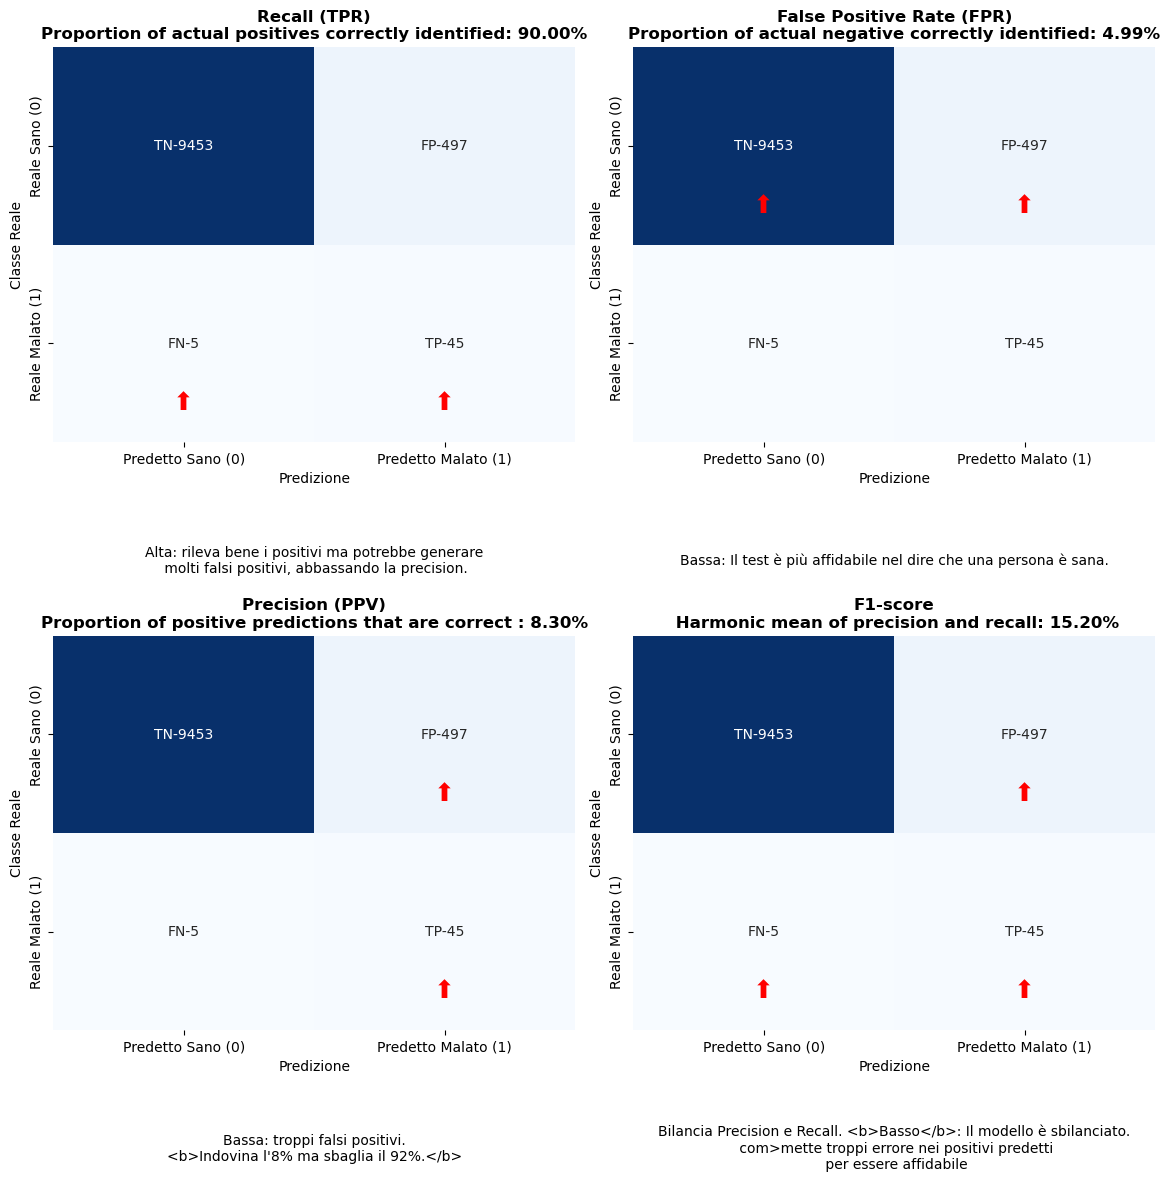

In [336]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Esempio di valori della matrice di confusione
TP, FN, FP, TN = 45, 5, 497, 9453  # Valori di esempio
conf_matrix = np.array([[TN, FP], [FN, TP]])

# Calcolo delle metriche
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
precision = TP / (TP + FP)
f1_score = 2 * (precision * recall) / (precision + recall)

# Dizionario delle metriche con descrizioni
metrics = {
    "Recall (TPR)\nProportion of actual positives correctly identified": {"value": recall, "formula": [(1, 1), (1, 0)], 
                      "desc": "Alta: rileva bene i positivi ma potrebbe generare\n molti falsi positivi, abbassando la precision."},
    "False Positive Rate (FPR)\nProportion of actual negative correctly identified": {"value": fpr, "formula": [(0, 1), (0, 0)], 
                                   "desc": "Bassa: Il test è più affidabile nel dire che una persona è sana."},
    "Precision (PPV)\nProportion of positive predictions that are correct ": {"value": precision, "formula": [(1, 1), (0, 1)], 
                         "desc": "Bassa: troppi falsi positivi.\n<b>Indovina l'8% ma sbaglia il 92%.</b>"},
    "F1-score\n Harmonic mean of precision and recall": {"value": f1_score, "formula": [(1, 1), (0, 1), (1, 0)],  
                 "desc": "Bilancia Precision e Recall. <b>Basso</b>: Il modello è sbilanciato.\n com>mette troppi errore nei positivi predetti\n per essere affidabile"}
}

labels = np.array([["TN-9453", "FP-497"], ["FN-5", "TP-45"]])  # Label dei quadranti

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, (metric, data) in zip(axes, metrics.items()):
    sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Predetto Sano (0)", "Predetto Malato (1)"],
                yticklabels=["Reale Sano (0)", "Reale Malato (1)"])
    ax.set_title(f"{metric}: {data['value']:.2%}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predizione")
    ax.set_ylabel("Classe Reale")

    # Aggiunta delle frecce rosse nei quadranti usati per la metrica
    for (i, j) in data["formula"]:
        ax.annotate("⬆️", xy=(j + 0.5, i + 0.5), xytext=(j + 0.5, i + 0.8),
                    ha='center', va='center', fontsize=18, color='red')

    # Aggiunta della descrizione sotto il grafico
    ax.text(0.5, -0.3, data["desc"], ha='center', va='center', fontsize=10, transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Interpretazione mia
Il modello è **molto bravo a trovare i malati (alta Recall = 90%)** ma ha una **bassa Precision (8.3%)**, quindi **molte persone sane ricevono un falso allarme (Molti FP)**.

Potrebbero avere usato una **soglia bassa** in modo da aumentare la recall e introdurre più falsi positivi. Essendo un test medico forse è più importante trovare il massimo numero di positivi, **evitanto la diagnosi di falsi negativi**. 

Anche se questo porta ansia nel generare tanti falsi positivi. Quindi un approccio più liberare rispetto uno conservativo con soglia alta magari usato nella prevenzione delle frodi.

## Svolgimento

### Step 1: Creazione di un Dataset Sintetico
Nel testo, la malattia colpisce solo 50 persone su 10.000, quindi la classe “positiva” (persone che sviluppano la malattia) è molto rara. Questo riflette un dataset sbilanciato, dove la maggior parte delle osservazioni appartiene alla classe negativa (persone sane). Provo a creare un data set dove l'età oltre i 35 anni influenza significativamente le varie feature e quindi i risultati dei test..

#### Distribuzione realistica dell'età in gravidanza:
* Utilizza una distribuzione beta scalata da 16 a 46 anni
* Aggiunge un picco attorno ai 30 anni
* Risulta in una distribuzione che rispecchia i dati reali con maggior frequenza nelle fasce 25-34 anni


#### Influenza dell'età su tutte le feature:

* Modifica tutte le 8 feature con un'influenza progressivamente maggiore quando l'età supera i 35 anni
* Ogni feature ha un diverso fattore di influenza, simulando il fatto che alcuni parametri biologici sono più sensibili all'età


#### Falsi positivi correlati all'età:

* Introduce un tasso di falsi positivi che aumenta con l'età
* Parte da circa 2% per donne giovani e arriva fino al 10% per le donne over 40

In [373]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.datasets import make_classification



# Creare il dataset di base
X, y = make_classification(
    n_samples=10000, 
    n_features=8, 
    n_classes=2, 
    weights=[0.995, 0.005],  # Classe 0 (sane) 99.5%, classe 1 (malati) 0.5%
    random_state=42
)

# Generare età con distribuzione più realistica per gravidanze
np.random.seed(42)
# Distribuzione dell'età che rispecchia maggiormente la realtà:
# - Picco tra 25-34 anni
# - Minore frequenza per età <20 e >40
# Utilizzo di una distribuzione beta scalata
age_distribution = np.random.beta(2, 2, size=X.shape[0])
# Scala da 16 a 46 anni
age = 16 + age_distribution * 30
# Aggiunge un picco intorno ai 30 anni
age = np.round(age + np.random.normal(0, 1, size=X.shape[0]) * 
              (np.abs(age-30) < 5) * 0.5).astype(int)
# Assicurarsi che le età rimangano nel range 16-46
age = np.clip(age, 16, 46).reshape(-1, 1)

# Creare un DataFrame
df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(X.shape[1])])
df['target'] = y
df['age'] = age

# Modificare tutte le feature per simulare l'aumento di rischio con età > 35
# L'effetto è maggiore per alcune feature rispetto ad altre
for i in range(1, 9):
    # Fattore di influenza diverso per ogni feature
    influence_factor = 0.2 + (i * 0.1)  # Aumenta progressivamente (0.3, 0.4, 0.5, ...)
    df.loc[df['age'] > 35, f'feature_{i}'] += (df.loc[df['age'] > 35, f'feature_{i}'] * influence_factor)

# Aggiungere rumore alle feature per le persone sane
for i in range(1, 9):
    noise_level = 1 + (i * 0.3)  # Diversi livelli di rumore
    df.loc[df['target'] == 0, f'feature_{i}'] += np.random.normal(0, noise_level, 
                                                                  size=(df.loc[df['target'] == 0].shape[0],))

# Aggiungere falsi positivi con probabilità crescente con l'età
base_fp_rate = 0.02  # Tasso di base per falsi positivi
age_factor = np.clip((df['age'] - 30) / 16, 0, 1)  # Fattore di aumento basato sull'età (0 a <30, max a 46)
fp_probability = base_fp_rate + (age_factor * 0.08)  # Fino a 10% per le età più avanzate

# Generare una maschera per i falsi positivi in base alla probabilità calcolata
random_values = np.random.rand(df.shape[0])
fp_mask = (df['target'] == 0) & (random_values < fp_probability)
df.loc[fp_mask, 'target'] = 1

In [374]:
df.head()


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,age
0,-0.315718,1.314063,-0.004960,2.398601,-1.572162,-7.209543,-0.179839,-1.030941,0,34
1,-2.127081,0.680384,0.718698,1.145576,-1.036507,0.873027,0.472371,5.689702,0,30
2,-1.467189,0.336517,-5.334665,0.401223,3.246276,-0.204014,-2.843231,5.161889,0,34
3,0.324824,-2.805701,-0.969930,0.348457,3.098126,3.833167,-1.576033,-4.388256,0,26
4,2.982233,-1.526420,-1.972497,5.986451,-7.353775,-7.423923,3.752587,-2.078840,0,43


In [375]:
# Suddividere in train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Istanzio il modello tendando di fargli gestire bene il set sbilanciato
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Precision: 0.9000
Recall: 0.4500
F1-Score: 0.6000


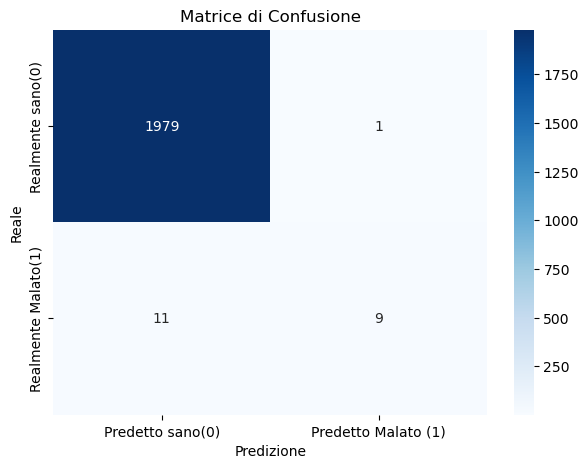

In [376]:
# Fare previsioni
y_pred = rf.predict(X_test)

# Calcolare le metriche
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Matrice di confusione per ottenere TP, FP, FN, TN
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Mostrare i risultati
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Predetto sano(0)", "Predetto Malato (1)"], yticklabels=["Realmente sano(0)", "Realmente Malato(1)"])
plt.title('Matrice di Confusione')
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.show()


### Mostro come fatto per i dati iniziali le 4 metriche (recall, fpr, precision, f1-score)

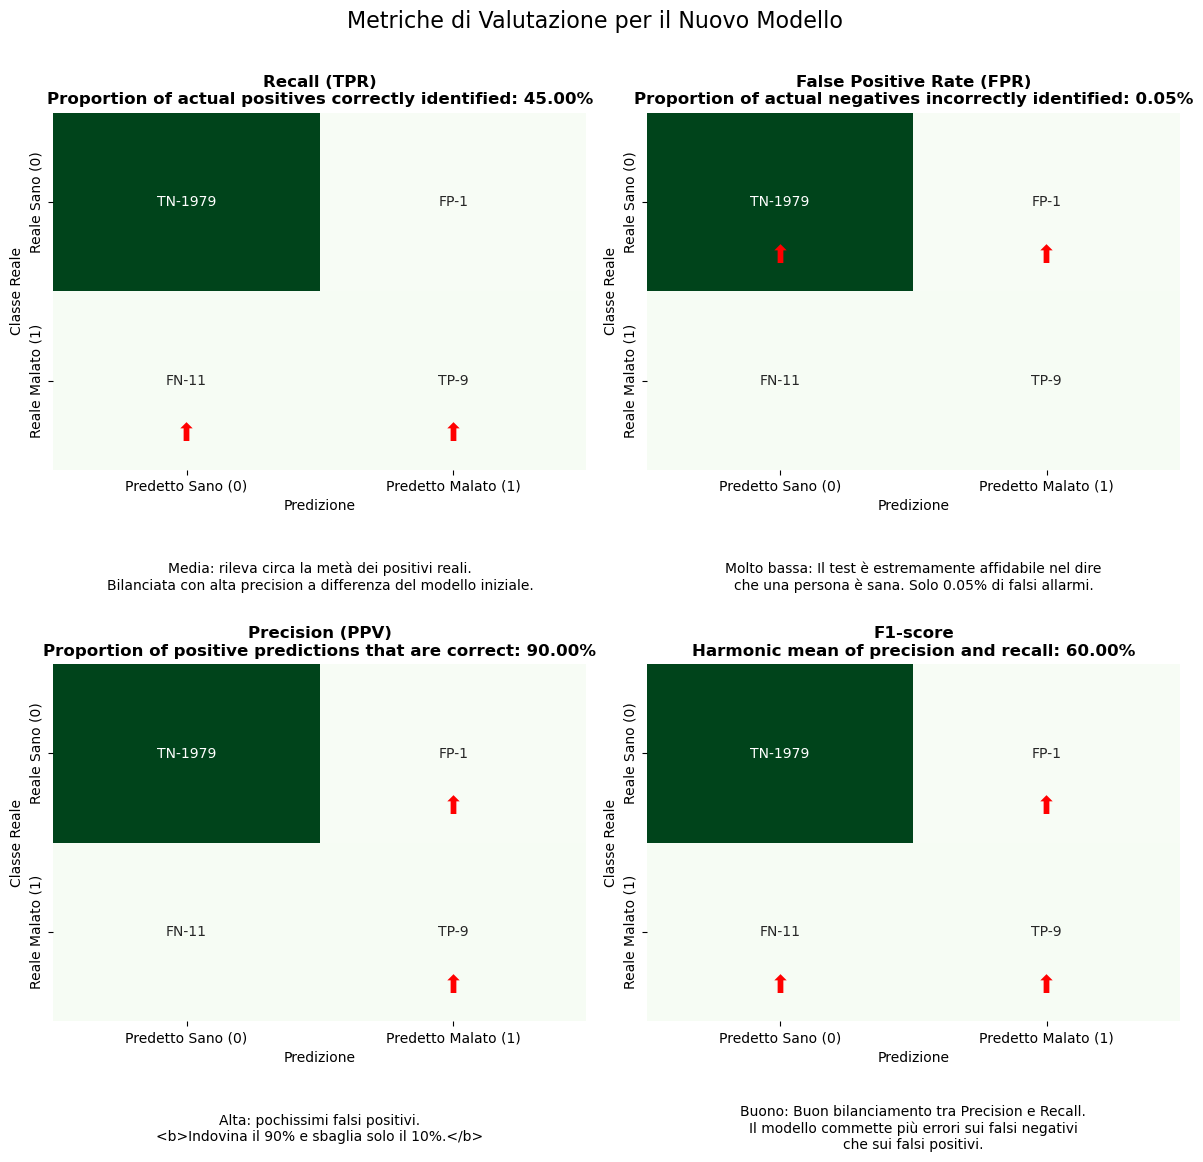

In [377]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Valori della matrice di confusione per il nuovo modello
TP, FN, FP, TN = 9, 11, 1, 1979  # Valori del nuovo modello
conf_matrix = np.array([[TN, FP], [FN, TP]])

# Calcolo delle metriche
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
precision = TP / (TP + FP)
f1_score = 2 * (precision * recall) / (precision + recall)

# Dizionario delle metriche con descrizioni
metrics = {
    "Recall (TPR)\nProportion of actual positives correctly identified": {"value": recall, "formula": [(1, 1), (1, 0)], 
                      "desc": "Media: rileva circa la metà dei positivi reali.\nBilanciata con alta precision a differenza del modello iniziale."},
    "False Positive Rate (FPR)\nProportion of actual negatives incorrectly identified": {"value": fpr, "formula": [(0, 1), (0, 0)], 
                                   "desc": "Molto bassa: Il test è estremamente affidabile nel dire\nche una persona è sana. Solo 0.05% di falsi allarmi."},
    "Precision (PPV)\nProportion of positive predictions that are correct": {"value": precision, "formula": [(1, 1), (0, 1)], 
                         "desc": "Alta: pochissimi falsi positivi.\n<b>Indovina il 90% e sbaglia solo il 10%.</b>"},
    "F1-score\nHarmonic mean of precision and recall": {"value": f1_score, "formula": [(1, 1), (0, 1), (1, 0)],  
                 "desc": "Buono: Buon bilanciamento tra Precision e Recall.\nIl modello commette più errori sui falsi negativi\nche sui falsi positivi."}
}

labels = np.array([["TN-1979", "FP-1"], ["FN-11", "TP-9"]])  # Label dei quadranti
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, (metric, data) in zip(axes, metrics.items()):
    sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Greens", cbar=False, ax=ax,
                xticklabels=["Predetto Sano (0)", "Predetto Malato (1)"],
                yticklabels=["Reale Sano (0)", "Reale Malato (1)"])
    ax.set_title(f"{metric}: {data['value']:.2%}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predizione")
    ax.set_ylabel("Classe Reale")
    
    # Aggiunta delle frecce rosse nei quadranti usati per la metrica
    for (i, j) in data["formula"]:
        ax.annotate("⬆️", xy=(j + 0.5, i + 0.5), xytext=(j + 0.5, i + 0.8),
                    ha='center', va='center', fontsize=18, color='red')
    
    # Aggiunta della descrizione sotto il grafico
    ax.text(0.5, -0.3, data["desc"], ha='center', va='center', fontsize=10, transform=ax.transAxes)

plt.suptitle("Metriche di Valutazione per il Nuovo Modello", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Confronto il mio modello con i dati iniziali

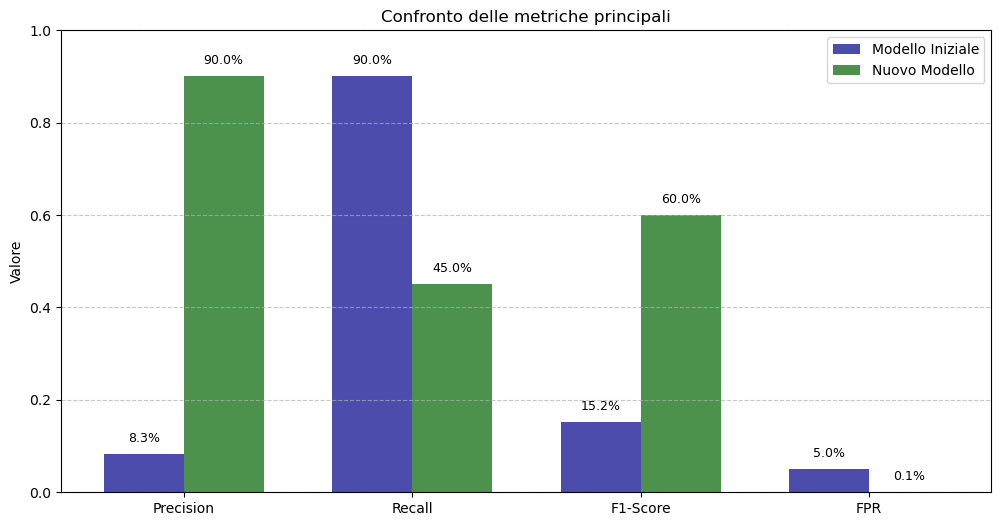

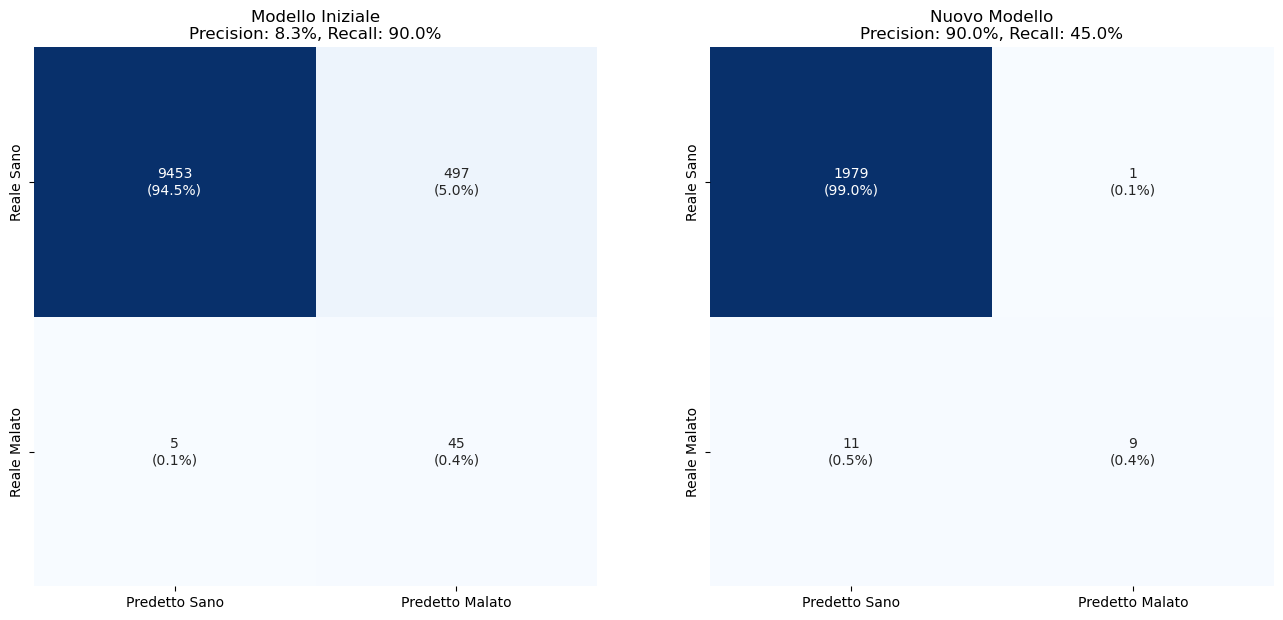

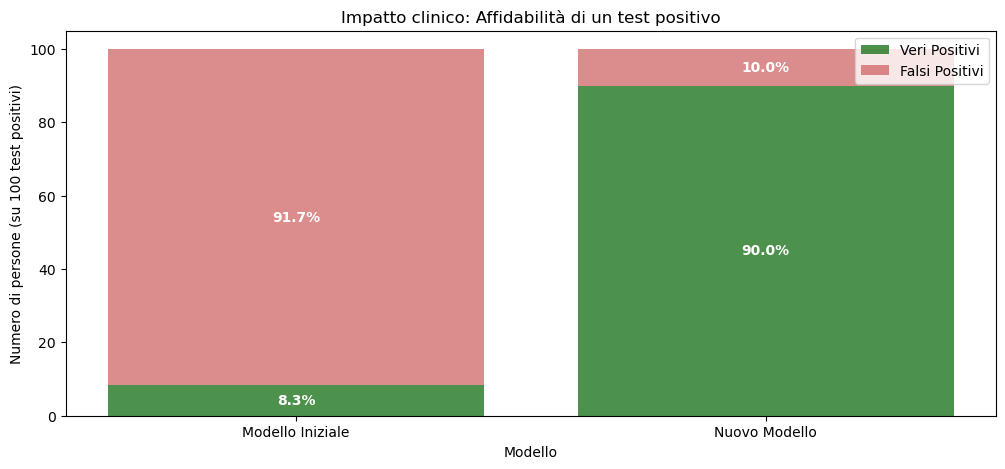

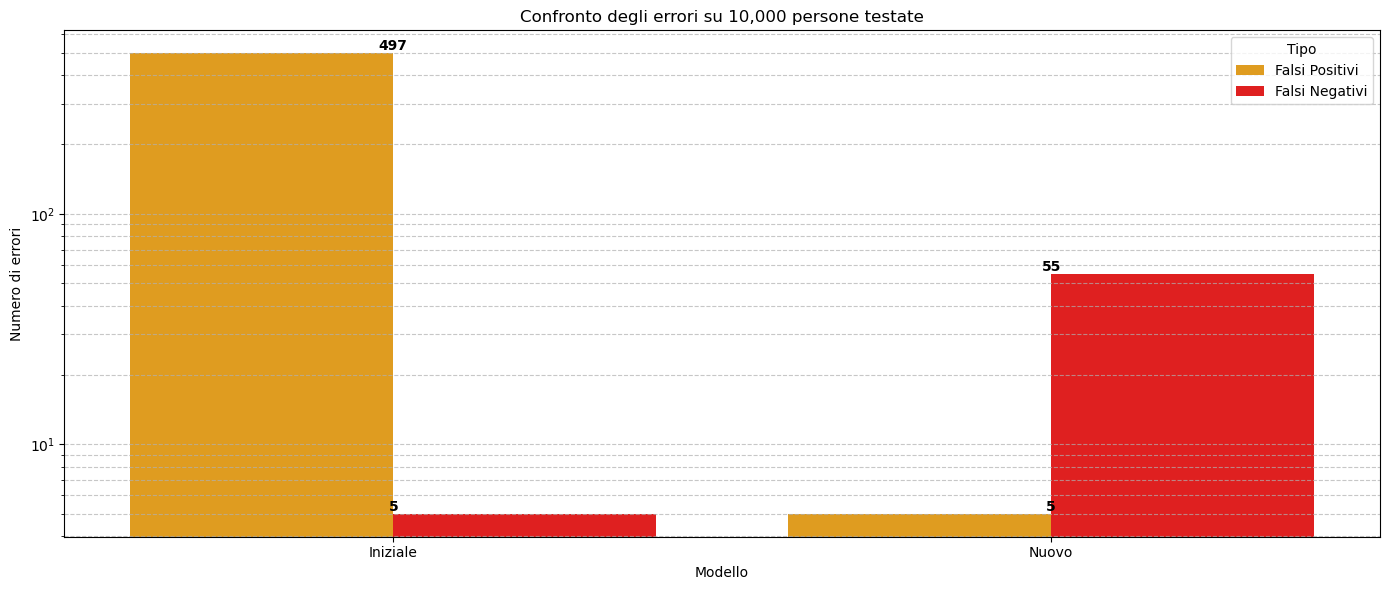

In [378]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Dati iniziali e del nuovo modello
models = {
    "Modello Iniziale": {
        "confusion_matrix": np.array([[9453, 497], [5, 45]]),
        "metrics": {
            "Precision": 0.083,
            "Recall": 0.9,
            "F1-Score": 0.152,
            "FPR": 0.05
        },
        "color": "darkblue"
    },
    "Nuovo Modello": {
        "confusion_matrix": np.array([[1979, 1], [11, 9]]),
        "metrics": {
            "Precision": 0.9,
            "Recall": 0.45,
            "F1-Score": 0.6,
            "FPR": 0.0005
        },
        "color": "darkgreen"
    }
}

# 1. Visualizzazione delle metriche principali
plt.figure(figsize=(12, 6))
metrics = ["Precision", "Recall", "F1-Score", "FPR"]
x = np.arange(len(metrics))
width = 0.35

for i, (model_name, model_data) in enumerate(models.items()):
    values = [model_data["metrics"][m] for m in metrics]
    plt.bar(x + (i-0.5)*width, values, width, label=model_name, color=model_data["color"], alpha=0.7)

plt.xticks(x, metrics)
plt.ylabel('Valore')
plt.title('Confronto delle metriche principali')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (model_name, model_data) in enumerate(models.items()):
    values = [model_data["metrics"][m] for m in metrics]
    for j, v in enumerate(values):
        plt.text(j + (i-0.5)*width, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontsize=9)

# 2. Visualizzazione comparativa delle matrici di confusione con rappresentazione visiva
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, (model_name, model_data) in enumerate(models.items()):
    conf_mat = model_data["confusion_matrix"]
    
    # Normalizzare per dimensioni diverse dei dataset
    totale = conf_mat.sum()
    conf_mat_percent = conf_mat / totale * 100
    
    # Aggiungere testo per le celle
    labels = []
    for r in range(2):
        row = []
        for c in range(2):
            count = conf_mat[r, c]
            perc = conf_mat_percent[r, c]
            row.append(f"{count}\n({perc:.1f}%)")
        labels.append(row)
    
    # Creare heatmap
    sns.heatmap(conf_mat_percent, annot=np.array(labels), fmt="", cmap="Blues", 
                ax=axes[i], cbar=False,
                xticklabels=["Predetto Sano", "Predetto Malato"],
                yticklabels=["Reale Sano", "Reale Malato"])
    
    axes[i].set_title(f"{model_name}\nPrecision: {model_data['metrics']['Precision']:.1%}, Recall: {model_data['metrics']['Recall']:.1%}")

# 3. Impatto clinico su 100 persone testate positive
fig, ax = plt.subplots(figsize=(12, 5))

# Per ogni 100 persone con test positivo
width = 0.8
true_positives = [8.3, 90]  # Valori di precision in percentuale
false_positives = [91.7, 10]  # Complemento a 100

labels = ["Modello Iniziale", "Nuovo Modello"]
x = np.arange(len(labels))

ax.bar(x, true_positives, width, label='Veri Positivi', color='darkgreen', alpha=0.7)
ax.bar(x, false_positives, width, bottom=true_positives, label='Falsi Positivi', color='indianred', alpha=0.7)

ax.set_ylabel('Numero di persone (su 100 test positivi)')
ax.set_xlabel('Modello')
ax.set_title('Impatto clinico: Affidabilità di un test positivo')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Aggiunta testo nelle barre
for i in range(len(x)):
    # Testo per veri positivi
    ax.text(i, true_positives[i]/2, f'{true_positives[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    # Testo per falsi positivi
    ax.text(i, true_positives[i] + false_positives[i]/2, f'{false_positives[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold')

# 4. Trade-off tra falsi positivi e falsi negativi per 10,000 persone
fig, ax = plt.subplots(figsize=(14, 6))

# Calcolo dei numeri per 10,000 persone
prevalence_initial = 0.005  # 0.5%
prevalence_new = 0.01      # 1%

# Modello iniziale
initial_tested = 10000
initial_TP = 45  # dato diretto
initial_FN = 5   # dato diretto
initial_FP = 497 # dato diretto
initial_TN = 9453  # dato diretto

# Modello nuovo - normalizzare a 10,000 persone
new_tested = 10000
new_scale = new_tested / 2000  # fattore di scala
new_TP = int(9 * new_scale)    # scalare a 10,000
new_FN = int(11 * new_scale)   # scalare a 10,000
new_FP = int(1 * new_scale)    # scalare a 10,000
new_TN = int(1979 * new_scale) # scalare a 10,000

# Creazione del dataframe per il grafico
data = pd.DataFrame({
    'Modello': ['Iniziale', 'Iniziale', 'Nuovo', 'Nuovo'],
    'Tipo': ['Falsi Positivi', 'Falsi Negativi', 'Falsi Positivi', 'Falsi Negativi'],
    'Conteggio': [initial_FP, initial_FN, new_FP, new_FN]
})

# Creazione del grafico
sns.barplot(x='Modello', y='Conteggio', hue='Tipo', data=data, palette={'Falsi Positivi': 'orange', 'Falsi Negativi': 'red'})
plt.title('Confronto degli errori su 10,000 persone testate')
plt.ylabel('Numero di errori')
plt.yscale('log')  # Scala logaritmica per visualizzare meglio le differenze
plt.grid(axis='y', which='both', linestyle='--', alpha=0.7)

# Aggiunta testo nelle barre
for i, row in data.iterrows():
    plt.text(i//2, row['Conteggio'], f'{int(row["Conteggio"])}', 
             ha='center', va='bottom', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

### COnsiderazioni sul mio modello
Avere molti più falsi negativi che falsi positivi significa che il test tende a "perdere" i casi malati piuttosto che generare falsi allarmi. In pratica:

**Il test sbaglia principalmente "in una direzione": dice che persone malate sono sane**
C'è un rischio significativo che condizioni patologiche non vengano rilevate
I pazienti potrebbero ricevere rassicurazioni ingiustificate e ritardare trattamenti necessari

#### Più veri positivi che falsi positivi
**Avere più veri positivi che falsi positivi significa che quando il test dà un risultato positivo, è più probabile che sia corretto piuttosto che un falso allarme**. In pratica:

* Un **risultato positivo è molto affidabile** (90% di precisione)
* I medici possono avere alta fiducia in un risultato positivo
* Si riducono drasticamente esami e procedure di follow-up non necessari

#### Implicazioni cliniche complessive
Queste caratteristiche rendono il nuovo modello:

* **Eccellente come test di conferma**: Quando hai bisogno di essere sicuro che un risultato positivo sia realmente positivo
* **Problematico come test di screening**: Non è ideale per la diagnosi precoce o lo screening di massa, dato che perde oltre la metà dei casi reali

#### Adatto in situazioni specifiche, come:

* Quando i falsi positivi sono particolarmente costosi o traumatici
* Quando si vuole ridurre il sovratrattamento
* **Come secondo test dopo un test di screening più sensibile**


#### Inadatto in altre situazioni, come:

* Screening di malattie gravi dove non rilevare un caso ha conseguenze serie
* **Contesti dove è prioritaria la diagnosi precoce**
* Situazioni dove è importante non perdere nessun caso positivo



In sintesi, il nuovo modello potrebbe essere descritto come "conservativo": **raramente dà l'allarme, ma quando lo fa è molto probabile che abbia ragione**.
Questo approccio può essere ottimale o problematico a seconda della specifica condizione clinica, della sua gravità, e dell'obiettivo del test diagnostico.